<a href="https://colab.research.google.com/github/mdmehedihasan/diffusion_feb_25/blob/intro_diffusion/Measure_Stable_Diffusion_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.0 MB/s eta 0:00:00


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

vae/config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

unet/config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

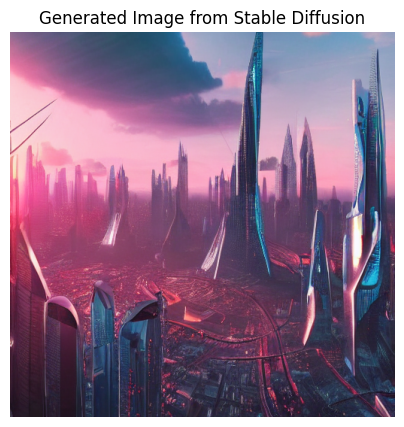

,Metric,Value
0,Inference Latency (s),24.38 seconds
1,Memory Used (GB),0.01 GB
2,Estimated Power Consumption (W),42.28 Watts


In [1]:
# Install necessary libraries
!pip install diffusers transformers accelerate torch torchvision numpy matplotlib pynvml pandas -q

import torch
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from diffusers import StableDiffusionPipeline
import pynvml

# Initialize GPU information
pynvml.nvmlInit()
device_id = 0  # Default to first GPU
handle = pynvml.nvmlDeviceGetHandleByIndex(device_id)

# Load Stable Diffusion Model
device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5").to(device)

# Function to measure latency, memory, and power usage
def measure_performance(prompt="A futuristic city at sunset", height=512, width=512, steps=50):
    torch.cuda.empty_cache()  # Clear cache to get accurate memory readings

    # Measure Memory Before Inference
    mem_before = torch.cuda.memory_allocated(device) / (1024**3)  # GB
    power_before = pynvml.nvmlDeviceGetPowerUsage(handle) / 1000  # Watts

    # Measure Latency
    start_time = time.time()
    image = pipe(prompt, height=height, width=width, num_inference_steps=steps).images[0]
    end_time = time.time()

    # Measure Memory After Inference
    mem_after = torch.cuda.memory_allocated(device) / (1024**3)  # GB
    power_after = pynvml.nvmlDeviceGetPowerUsage(handle) / 1000  # Watts

    # Compute Performance Metrics
    latency = end_time - start_time
    memory_used = mem_after - mem_before
    avg_power = (power_before + power_after) / 2  # Approximate average power usage

    return latency, memory_used, avg_power, image

# Run the test
latency, memory_used, avg_power, img = measure_performance()

# Create a DataFrame for table format output
df = pd.DataFrame({
    "Metric": ["Inference Latency (s)", "Memory Used (GB)", "Estimated Power Consumption (W)"],
    "Value": [f"{latency:.2f} seconds", f"{memory_used:.2f} GB", f"{avg_power:.2f} Watts"]
})

# Display the generated image
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Generated Image from Stable Diffusion")
plt.show()

# Display table of performance metrics
from IPython.display import display
display(df)
